# Notebook 1: Exploratory Data Analysis
## Mushroom Dataset 


#### Final Project: DSC 345/445
#### Victoria Burke and Rebecca Henzig


Our dataset is the Mushroom Dataset from the UC Irvine Machine Learning Repository. It can be found here: [https://archive.ics.uci.edu/dataset/73/mushroom]

The dataset contains 8124 entries of mushrooms from *The Audubon Society Field Guide to North American Mushrooms*. For each mushroom entry, there are variables corresponding to physical characteristics about the mushroom. All mushrooms are from the two genera Agaricus and Lepiota. Agaricus is the most commonly cultivated mushroom genus for consumption. The Lepiota genus, of which some species look very similar to Agaricus mushrooms, contains many toxic and even deadly varieties. 

The objective of our models is to classify the mushrooms in the dataset as either edible or poisonous based on their physical characteristics. It is especially important that our models have high recall, as the cost of misclassifying a poisonous mushroom as edible is much higher than the other way around. The genus of the mushrooms is **not** one of the predictor variables available; the models will perform classification solely based on physical traits. 

### Load data

Column names were obtained from the supplementary file ``agaricus-lepiota.names``. As ``agaricus-lepiota.data`` is simply a matrix of text with no labels, this file provides the information necessary to label the columns.

As shown below, the entries in the data table are single letters. ``agaricus-lepiota.names`` also contains the meaning of these codes for each of the variables.


In [13]:
import pandas as pd 
import matplotlib.pyplot as plt

# loading data and labeling columns
columns = ['target', 'cap-shape', 'cap-surface', 'cap-color', 'bruises',
           'odor', 'gill-attachment', 'gill-spacing', 'gill-size',
           'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
           'stalk-surface-below-ring', 'stalk-color-above-ring',
           'stalk-color-below-ring', 'veil-type', 'veil-color',
           'ring-number', 'ring-type', 'spore-print-color',
           'population', 'habitat']

df = pd.read_csv('../data/agaricus-lepiota.data', header = None, names = columns)

df.head()

,target,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [14]:
df.shape

(8124, 23)

The dataset contains 8124 rows (8124 mushroom entries) and 23 columns. 22 of these columns are independent variables/predictors. The first column contains the variable of interest (poisonous/edible).

All 23 variables are categorical. There are no numeric (or even ordinal) variables.

### Exploration of target variable

target
e    4208
p    3916
Name: count, dtype: int64


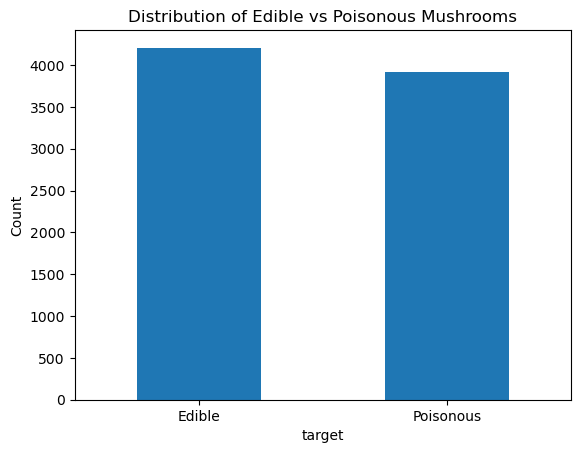

In [15]:
print(df['target'].value_counts())

df['target'].value_counts().plot(kind = 'bar')
plt.title('Distribution of Edible vs Poisonous Mushrooms')
plt.xticks(ticks=[0, 1], labels=['Edible', 'Poisonous'], rotation=0)
plt.ylabel('Count')
plt.savefig('../results/target_distribution.png')
plt.show()

As shown in the barplot above, there is an equal class distribution in this dataset. There are slightly more edible (n=4208) than poisonous (n=3916) mushrooms, but this is a small margin. There are plenty of samples of each class for training the model, and class imbalance should not be a concern when creating models.

### Missing values

A simple check for null/NaN values shows that no missing values are encoded in the standard null/NaN format in the dataset, for any of the variables.

In [6]:
print(df.isnull().sum())

target                      0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


``agaricus-lepiota.names`` has a section explaining missing values in the dataset, which says that the ``stalk-root`` variable contains 2480 missing values, signified by a "?". Our code check confirms this: 

In [7]:
# stalk-root missing vals
for col in df.columns:
    if '?' in df[col].values:
        count = (df[col] == '?').sum()
        print(f"{col}: {count} missing values")

stalk-root: 2480 missing values


Although we are confident that there are no other missing values as the documentation only says there are missing values in the ``stalk-root`` attribute, we will perform a check for the "?" symbol in each column to verify:

In [21]:
df.apply(lambda col: (col == '?').sum())

target                         0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

### Exploration of predictor variables

Since all variables are categorical, we can visualize their distributions in barplots:

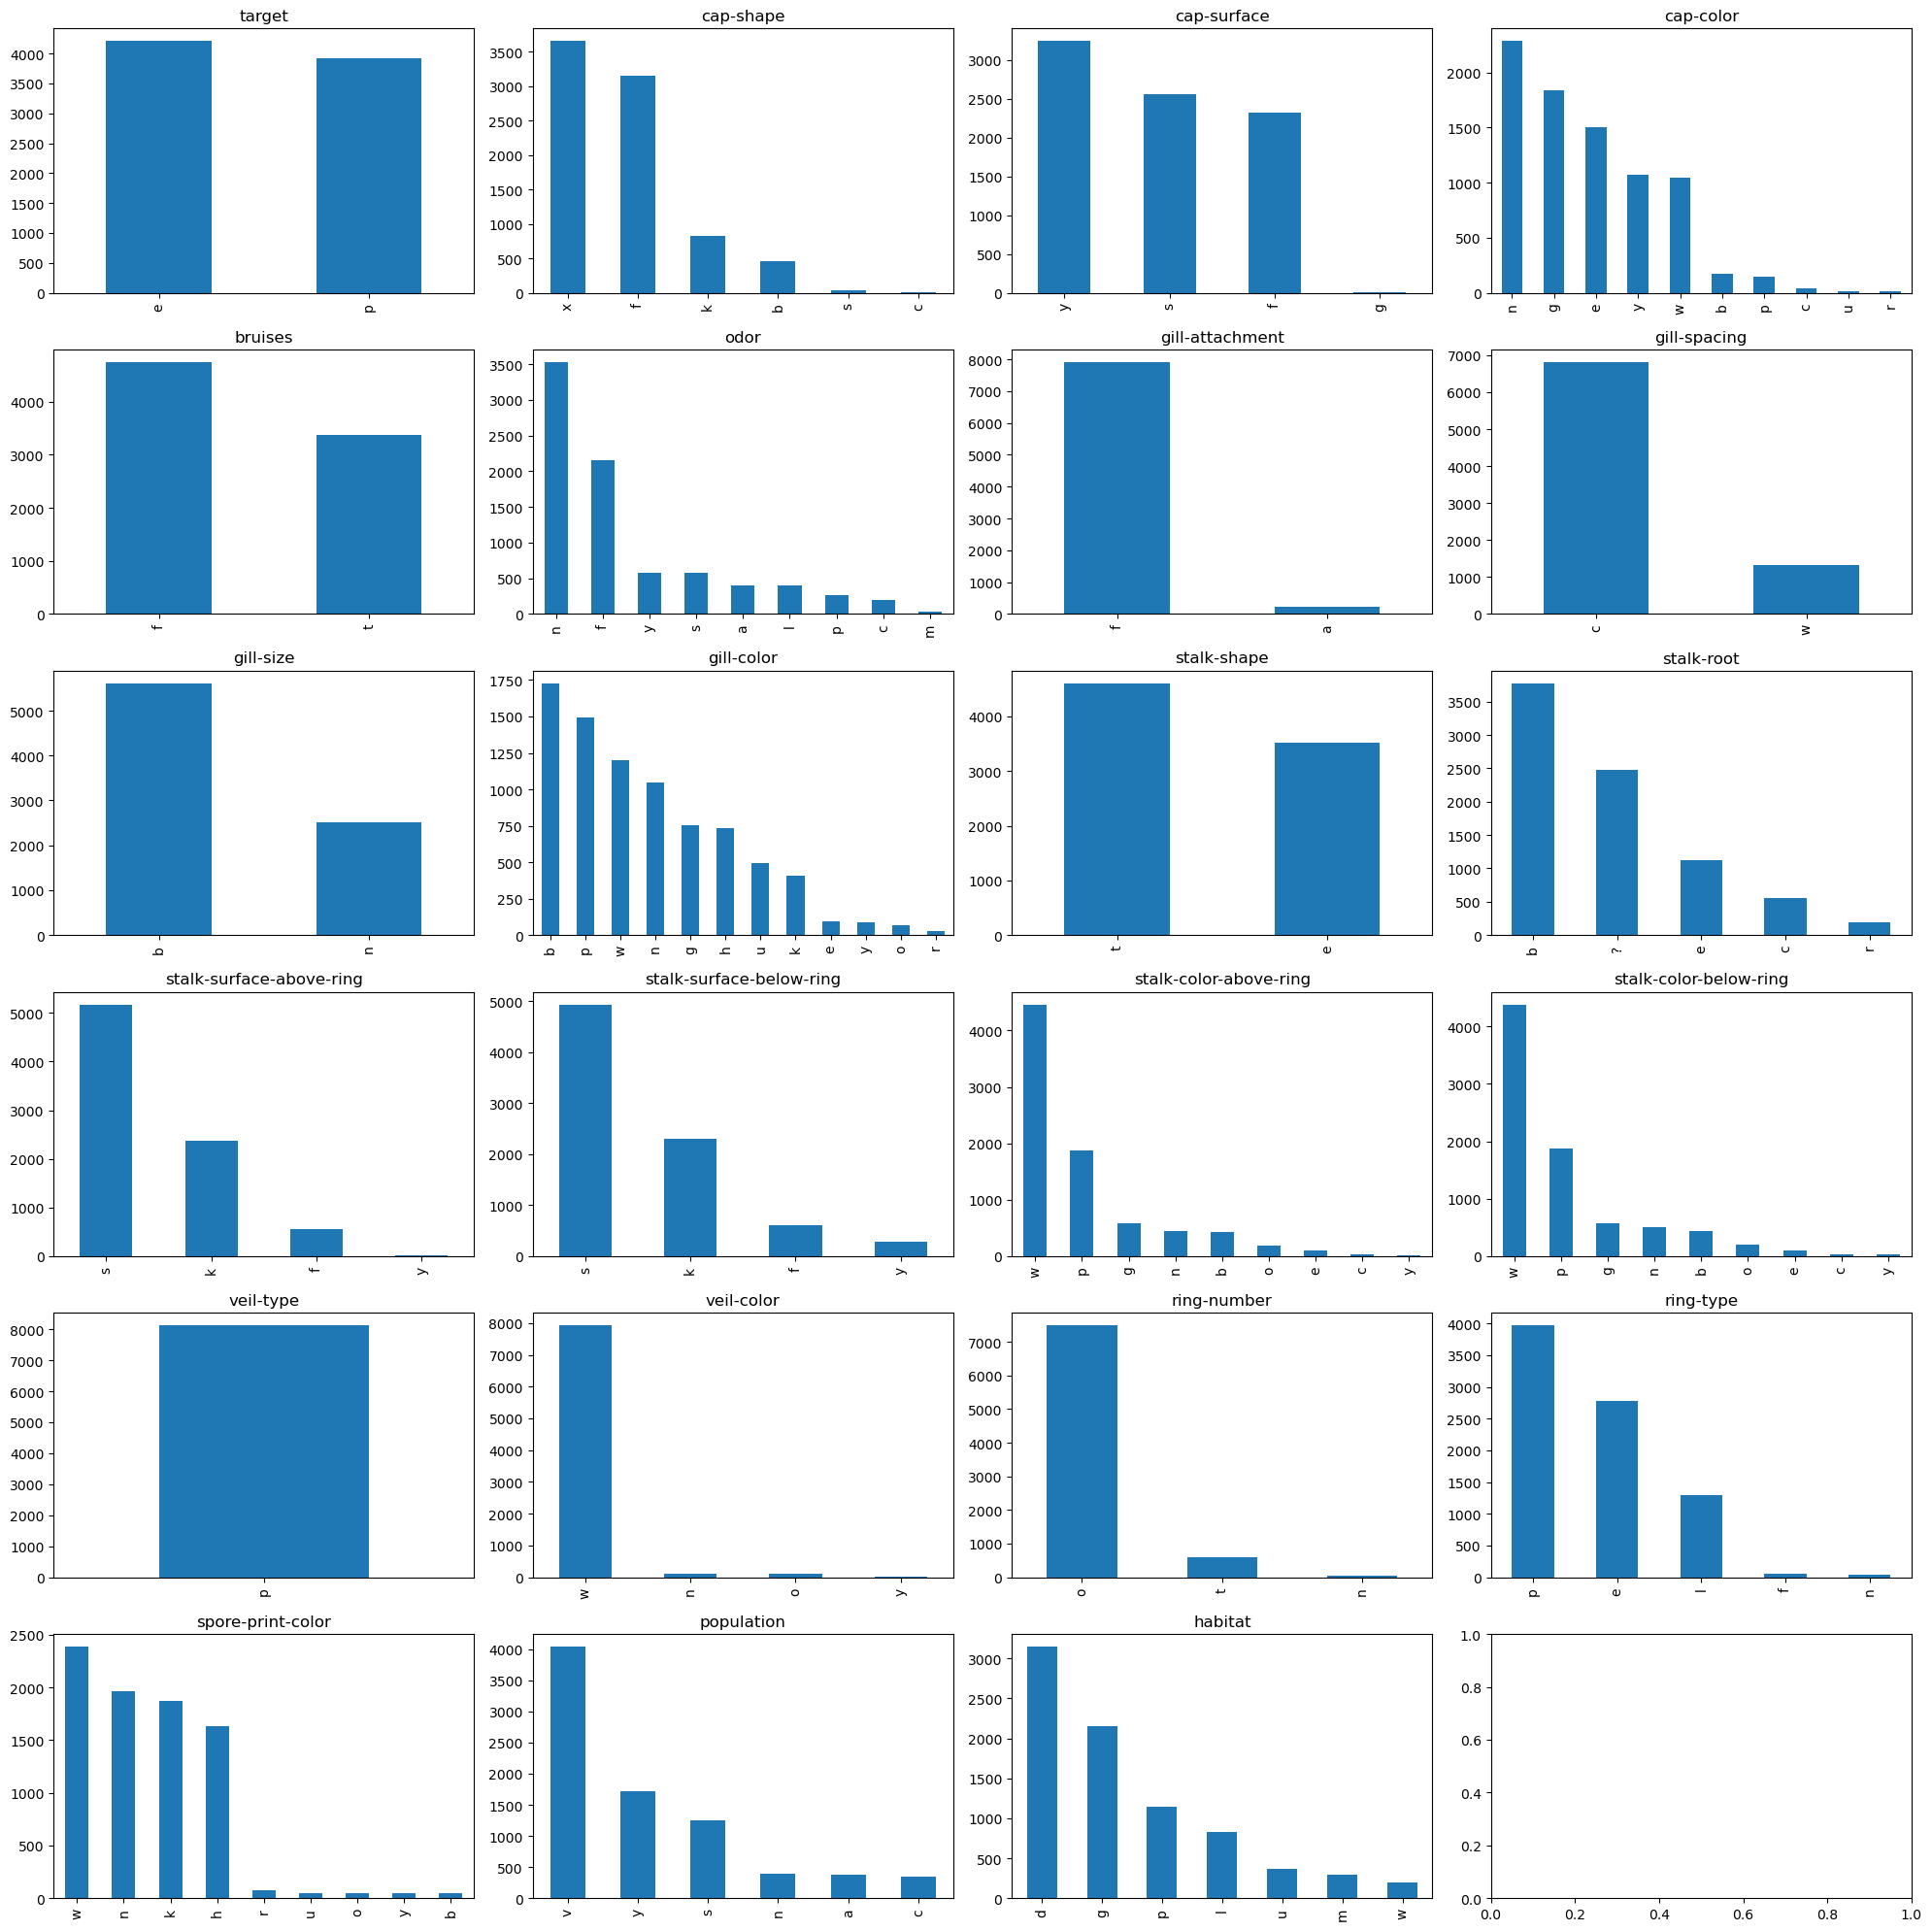

In [8]:
# Feature distributions
fig, axes = plt.subplots(nrows = 6, ncols = 4, figsize = (20, 20))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    df[col].value_counts().plot(kind = 'bar', ax = axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()


There are a variety of distributions present among the predictor variables. Also, it is important to note that some variables have more categories than others (e.g. ``gill_size`` has only 2 levels, whereas ``habitat`` has 7).

The variables ``veil-color``, ``ring-number``, and ``gill-attachment`` have very skewed distributions. The vast majority of samples are in the same category for these predictors. These may end up not being useful for classification, but they could also indicate a strong signal for either target class if all samples in the minority group correspond to a specific type of mushroom that is always poisonous/always nonpoisonous.

The variables ``gill-spacing``, ``gill-size``, ``stalk-surface-above-ring``, ``stalk-surface-below-ring``, ``stalk-color-above-ring``,  ``stalk-color-below-ring``, and ``population`` also have skewed distributions, but do still have a noticeable number of samples belonging to minority classes. These variables appear to describe similar things, which tells us that most mushrooms, at least those represented in this dataset, have a similar physical appearance in certain parts of their gills and stalks. 

``cap-shape``, ``cap-surface``, ``cap-color``, ``odor``, ``ring-type``, ``spore-print-color``, and ``habitat`` all have at least two class levels that are represented in a significant number of the samples (> 1500), and then some classes that are less common. 

``bruises`` and ``stalk-shape`` are both variables with only two categories present in the data (binary) and roughly balanced distributions.








#### Anomaly variables

``stalk-root`` has a significant number of missing values.

``veil-type`` has only one category present in the dataset. This will not be useful for model training, so we can get rid of it in our cleaning step.

In [24]:
len(df["veil-type"].unique())

1

### Chi-squared test

In order to compare our categorical variables, we implemented a Chi-square test to determine whether there is a relationship between each feature and the target variable. 

The results show that ``odor`` had the strongest association with the target variable, followed by ``spore-print-color``, ``gill-color``, and ``ring-type``. These features are most likely very useful for predicted whether a mushroom is edible or poisonous. 

On the other end of the spectrum, ``veil-type`` has a Chi-squared value of 0 and a p-value of 1, indicating no relationship with the target variable.

In [9]:
# chi-squared test
from scipy.stats import chi2_contingency

results = []
for col in df.drop(columns=['target']).columns:
    contingency_table = pd.crosstab(df[col], df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    results.append({'feature': col, 'chi2': chi2, 'p-value': p})
chi2_df = pd.DataFrame(results).sort_values('chi2', ascending=False)
print(chi2_df)

                     feature         chi2        p-value
4                       odor  7659.726740   0.000000e+00
19         spore-print-color  4602.033170   0.000000e+00
8                 gill-color  3765.714086   0.000000e+00
18                 ring-type  2956.619278   0.000000e+00
11  stalk-surface-above-ring  2808.286287   0.000000e+00
12  stalk-surface-below-ring  2684.474076   0.000000e+00
7                  gill-size  2366.834257   0.000000e+00
13    stalk-color-above-ring  2237.898496   0.000000e+00
14    stalk-color-below-ring  2152.390891   0.000000e+00
3                    bruises  2041.415647   0.000000e+00
20                population  1929.740891   0.000000e+00
21                   habitat  1573.777261   0.000000e+00
10                stalk-root  1344.440527  7.702048e-290
6               gill-spacing   984.143333  5.022978e-216
0                  cap-shape   489.919954  1.196457e-103
2                  cap-color   387.597769   6.055815e-78
17               ring-number   

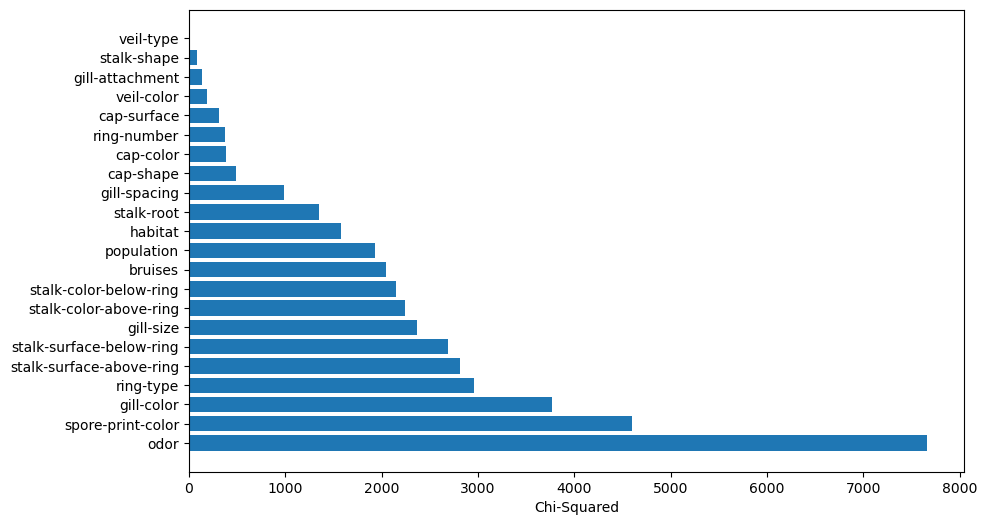

In [10]:
# visual for chi-squared
plt.figure(figsize=(10, 6))
plt.barh(chi2_df['feature'], chi2_df['chi2'])
plt.xlabel('Chi-Squared')
plt.savefig('../results/chi_squared.png')
plt.show()

### Clean data for model building

1. Stalk root variable
2. Because all entries for ``veil-type`` have the same value, this is not useful for prediction. We can drop it from the dataset for simplicity.

We will save the cleaned file as a new csv and use this to perform model training.

In [11]:
# cleaned data
df_model = df.copy()
df_model['stalk-root'] = df_model['stalk-root'].replace('?', 'unknown')
df_model = df_model.drop(columns=['veil-type'])
df_model.to_csv('../data/cleaned_mushrooms.csv', index=False)